First 5 rows of data:
   first_hour_likes  total_views
0               120         8500
1               340        22000
2                89         5200
3               510        41000
4               230        15000

Basic statistics:
       first_hour_likes   total_views
count         30.000000     30.000000
mean         312.800000  22893.333333
std          201.676662  16286.400786
min           45.000000   3200.000000
25%          125.000000   8750.000000
50%          300.000000  19750.000000
75%          462.500000  34250.000000
max          720.000000  58000.000000


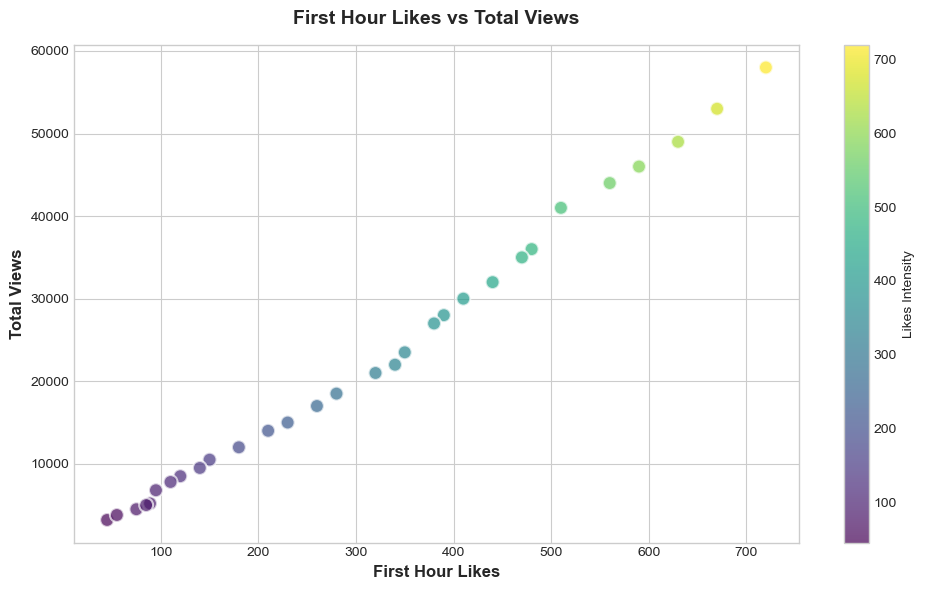


Model Parameters:
Slope (Coefficient): 79.85
Intercept: -2186.25

Predictions vs Actual:
   Actual  Predicted
0   35000    35344.0
1    4500     3803.0
2   30000    30553.0
3   36000    36143.0
4   10500     9792.0
5   58000    55307.0


C:\Users\Suresh Mandamanedi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


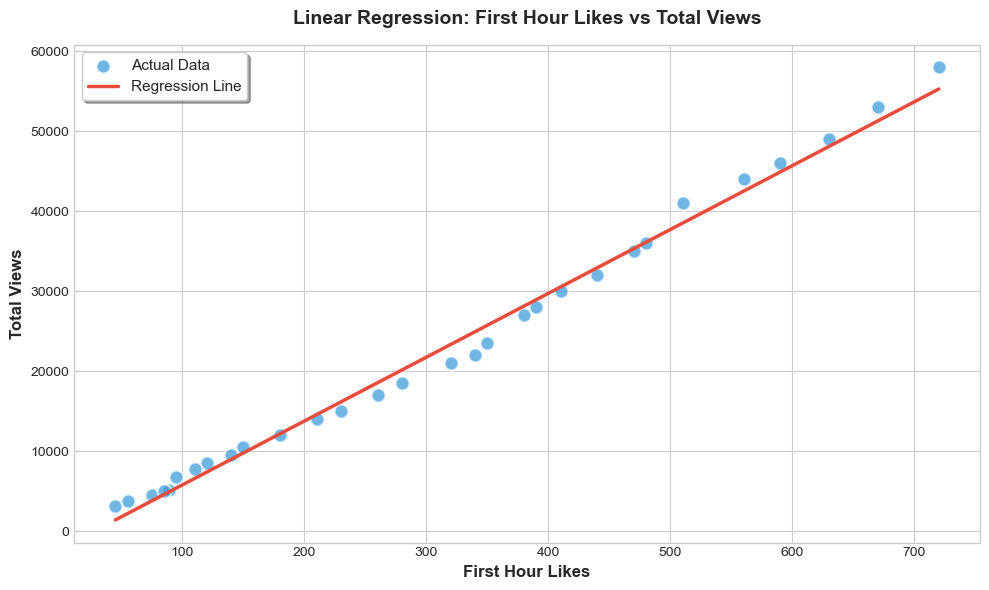


Raj's Question: If I get 750 first-hour likes, how many views?
Predicted Total Views: 57,702


C:\Users\Suresh Mandamanedi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Step 2: Create the Dataset
data = {
    'first_hour_likes': [120, 340, 89, 510, 230, 670, 45, 390, 150, 720,
                         280, 95, 440, 180, 560, 75, 320, 480, 210, 630,
                         110, 350, 85, 410, 260, 590, 140, 470, 55, 380],
    
    'total_views': [8500, 22000, 5200, 41000, 15000, 53000, 3200, 28000, 10500, 58000,
                    18500, 6800, 32000, 12000, 44000, 4500, 21000, 36000, 14000, 49000,
                    7800, 23500, 5000, 30000, 17000, 46000, 9500, 35000, 3800, 27000]
}

df = pd.DataFrame(data)

# Step 3: Explore the Data
print("First 5 rows of data:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())

# Step 4: Visualize the Data
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.scatter(df['first_hour_likes'], df['total_views'],
            c=df['first_hour_likes'], cmap='viridis', s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
plt.colorbar(label='Likes Intensity')
plt.xlabel('First Hour Likes', fontsize=12, fontweight='bold')
plt.ylabel('Total Views', fontsize=12, fontweight='bold')
plt.title('First Hour Likes vs Total Views', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Step 5: Prepare Data for Training
X = df[['first_hour_likes']]  # Features (must be 2D)
y = df['total_views']          # Target

# Step 6: Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Create and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Check Model Parameters
print("\nModel Parameters:")
print(f"Slope (Coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

# Step 9: Make Predictions on Test Data
y_pred = model.predict(X_test)

print("\nPredictions vs Actual:")
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round()})
print(results)

# Step 10: Visualize the Regression Line
plt.figure(figsize=(10, 6))
plt.scatter(df['first_hour_likes'], df['total_views'],
            c='#3498db', s=100, alpha=0.7, edgecolors='white', linewidth=1.5, label='Actual Data')
X_line = np.linspace(df['first_hour_likes'].min(), df['first_hour_likes'].max(), 100).reshape(-1, 1)
plt.plot(X_line, model.predict(X_line), color='#e74c3c', linewidth=2.5, label='Regression Line')
plt.xlabel('First Hour Likes', fontsize=12, fontweight='bold')
plt.ylabel('Total Views', fontsize=12, fontweight='bold')
plt.title('Linear Regression: First Hour Likes vs Total Views', fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()

# Step 11: Answer Raj's Question
new_likes = 750
predicted_views = model.predict([[new_likes]])
print(f"\nRaj's Question: If I get {new_likes} first-hour likes, how many views?")
print(f"Predicted Total Views: {predicted_views[0]:,.0f}")
